In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
import tifffile
from skimage.measure import regionprops_table
import random
from matplotlib.colors import BoundaryNorm

import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score, silhouette_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import adjusted_mutual_info_score
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
# Consistent colours for the three cell types.
CT_ORDER = ["endothelial", "fibroblast", "unknown"]
CT_COLORS = {"endothelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}
true_gene_columns = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']
all_data = pd.read_csv("clean_data_with_assigned_cell_type.csv")
X = all_data[list(true_gene_columns)].astype(int).to_numpy()


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**,
which we relate back to gene state - and we then test whether whole gene states
(e.g. `1_4_7` vs `1_4_8`) co-locate in space.


In [52]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% endothelial / fibroblast / unknown)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within a fixed radius)


K_SPATIAL = 15         # neighbours used for composition / expression
RADIUS_UM = 30.0       # radius (microns) used for the local-density count

ct_dummies = (pd.get_dummies(df["cell_type"])
              .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

feat_ct   = np.zeros((len(df), len(CT_ORDER)))
feat_gene = np.zeros((len(df), len(GENES)))
entropy   = np.zeros(len(df))
density   = np.zeros(len(df))

for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb   # drop self column
    gneigh = ii[neigh]                             # local -> global indices
    feat_ct[ii]   = ct_dummies[gneigh].mean(axis=1)
    feat_gene[ii] = X[gneigh].mean(axis=1)
    comp = feat_ct[ii]
    entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
    density[ii] = np.array([len(x) - 1 for x in tree.query_ball_point(coords, RADIUS_UM)])

nbhd = pd.DataFrame(feat_ct, columns=[f"nb_%{c}" for c in CT_ORDER], index=df.index)
nbhd = pd.concat(
    [nbhd, pd.DataFrame(feat_gene, columns=[f"nb_{g}" for g in GENES], index=df.index)],
    axis=1)
nbhd["nb_entropy"] = entropy
nbhd["nb_density"] = density
df[nbhd.columns] = nbhd


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_341584\3404930806.py:32: RuntimeWarning: divide by zero encountered in log
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_341584\3404930806.py:32: RuntimeWarning: invalid value encountered in multiply
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)


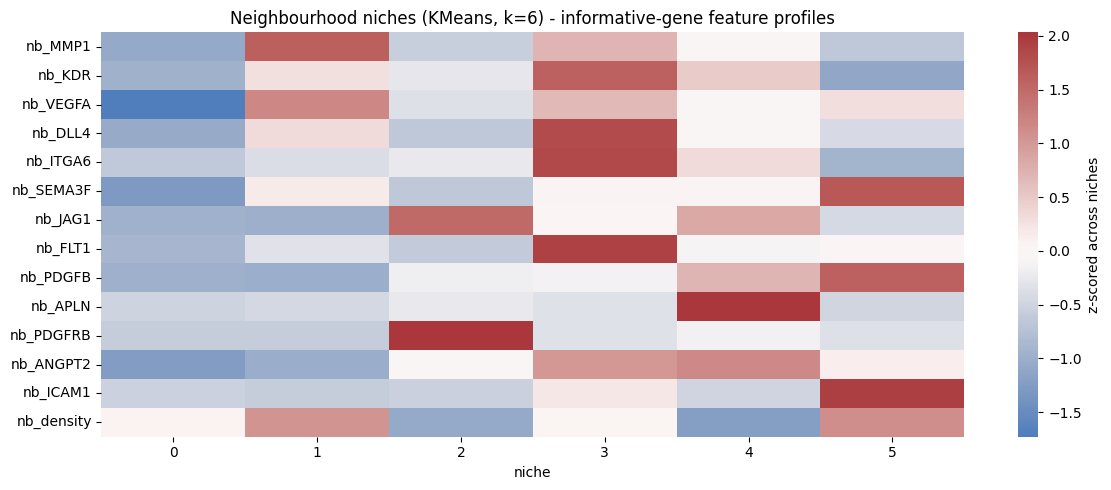

In [82]:
# Cluster the NEIGHBOURHOODS into recurring micro-environments ("niches"). The population
# is overwhelmingly endothelial, so cell-type composition, its Shannon entropy (which just
# measure "endothelial vs mixed"), and the lineage-defining markers dominate any clustering
# that includes them - niches then collapse onto an uninteresting endothelial-density axis.
# We therefore build niches from the NEIGHBOURHOOD EXPRESSION of the informative
# (non-marker) genes only, so niches reflect functional gene micro-environments.
NICHE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1", "COL1A1", "COL1A2"}
niche_genes = [g for g in GENES if g not in NICHE_MARKER_EXCLUDE]
nb_feature_cols = [f"nb_{g}" for g in niche_genes] + ["nb_density"]
Zf = StandardScaler().fit_transform(df[nb_feature_cols].values)

n_niches = 6
df["niche"] = KMeans(n_clusters=n_niches, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche (z-scored across niches so genes and density are comparable).
niche_profile = df.groupby("niche")[nb_feature_cols].mean()
niche_profile_z = (niche_profile - niche_profile.mean()) / (niche_profile.std() + 1e-9)
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile_z.T, cmap="vlag", center=0,
            cbar_kws={"label": "z-scored across niches"})
plt.title(f"Neighbourhood niches (KMeans, k={n_niches}) - informative-gene feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()

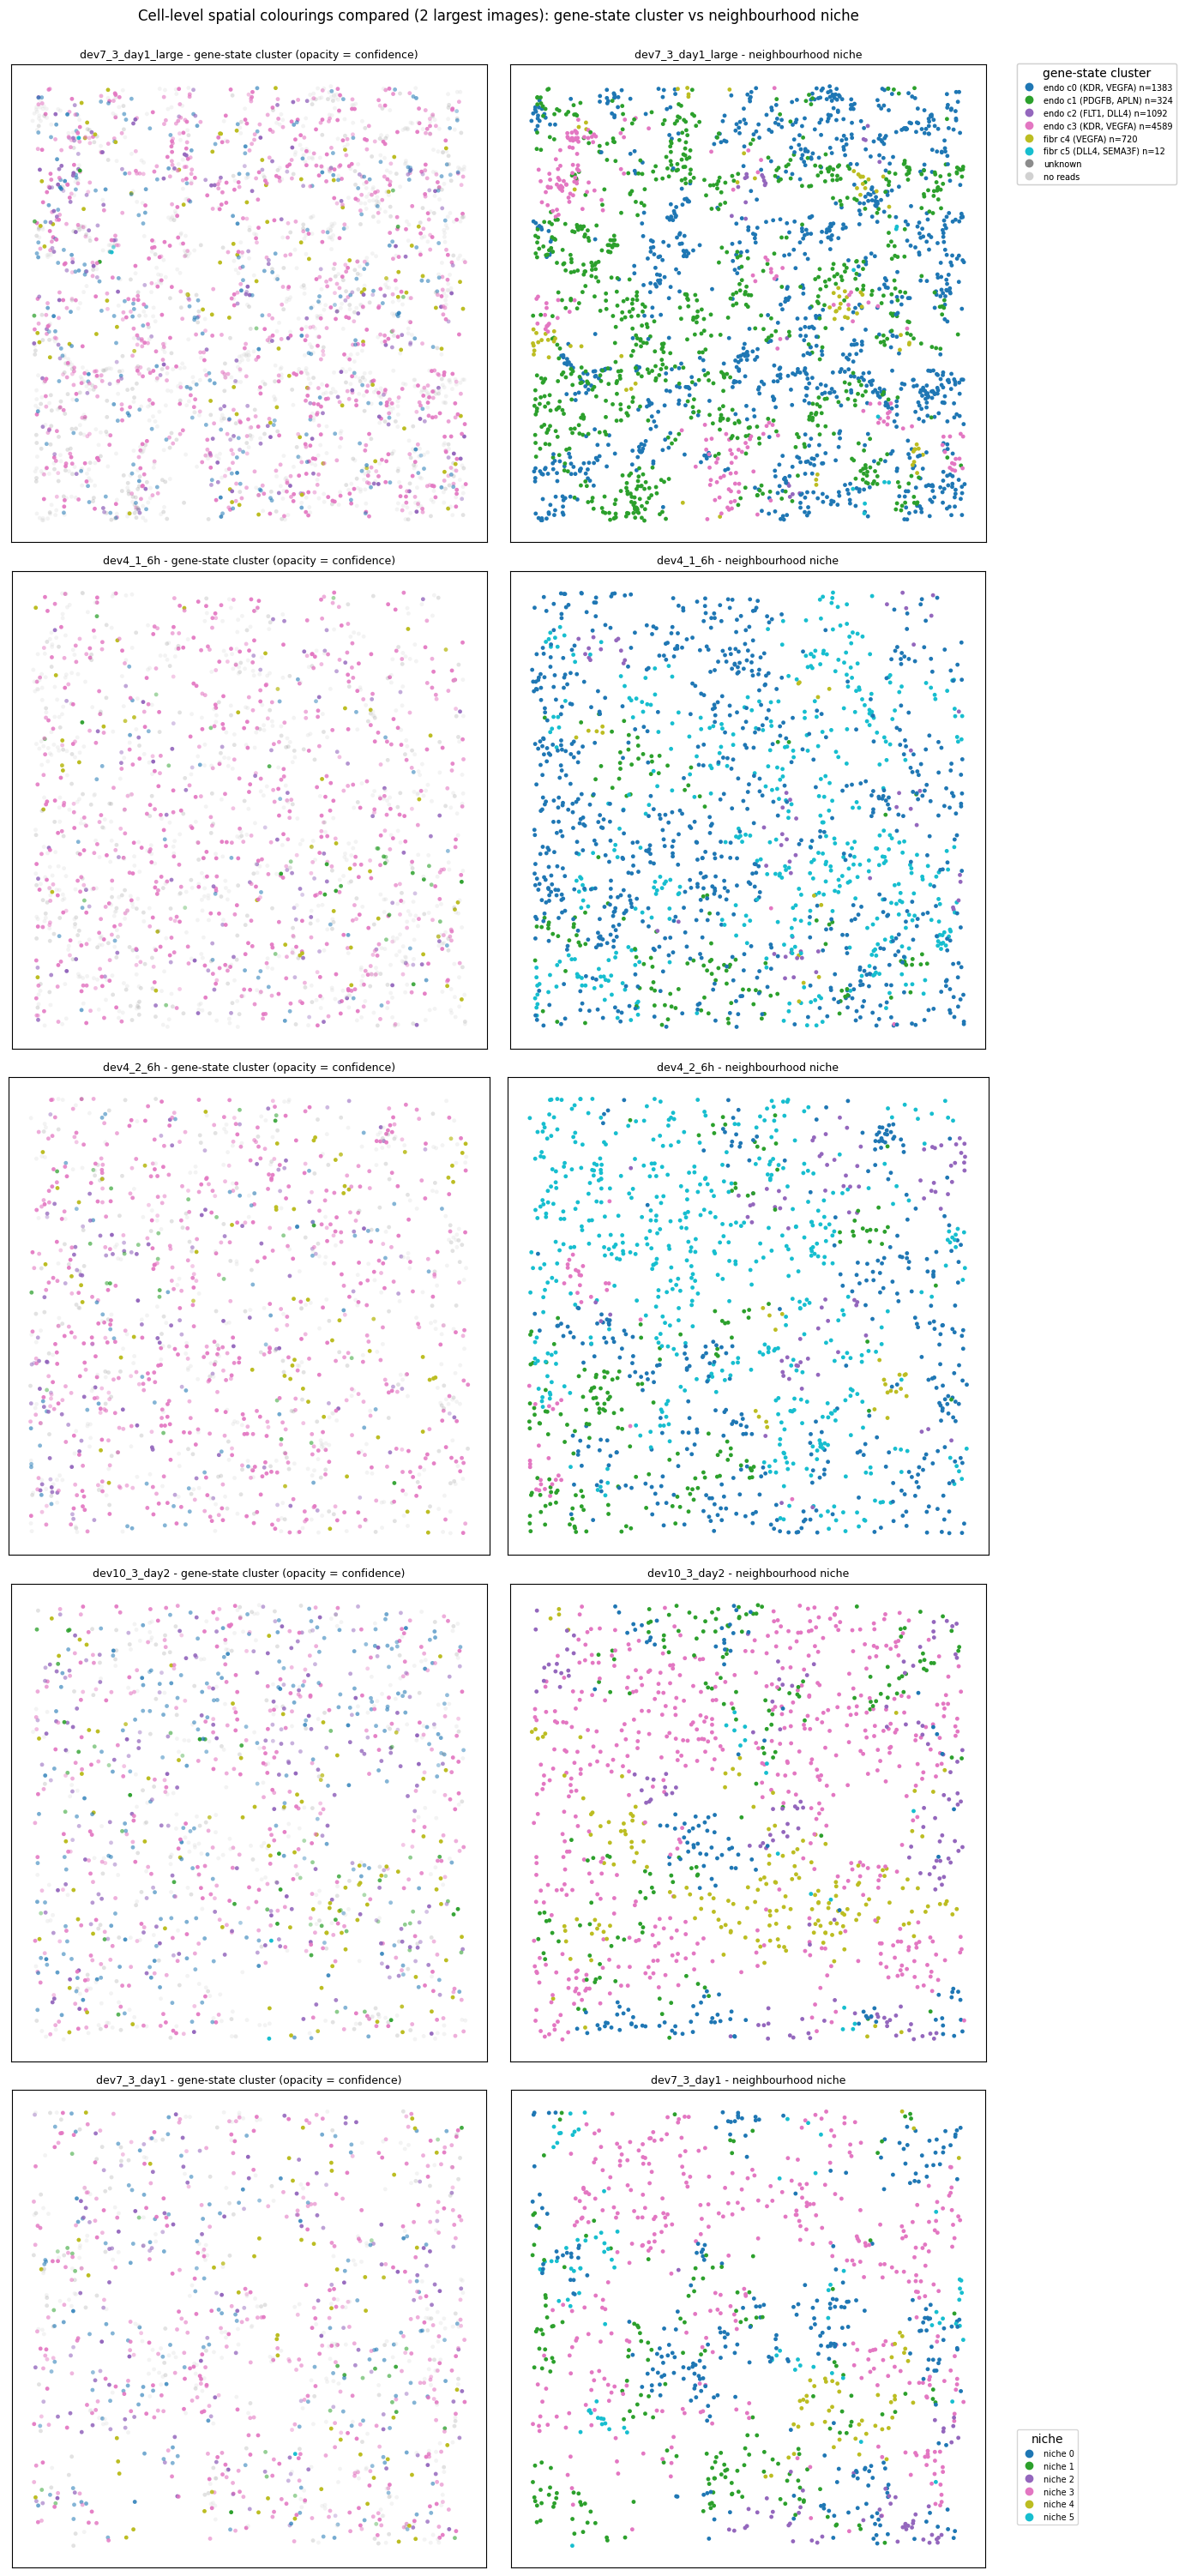

In [ ]:

# Gene-state cluster colours (opacity = assignment confidence; grey = unknown / no reads).
cluster_cmap = plt.get_cmap("tab10", len(cluster_names))
cluster_palette = {name: to_rgba(cluster_cmap(i)) for i, name in enumerate(cluster_names)}
cluster_palette["unknown"] = to_rgba("0.55")
cluster_palette["no reads"] = to_rgba("0.82")

# Neighbourhood niche colours.
niche_ids = np.sort(df["niche"].unique())
niche_cmap = plt.get_cmap("tab10", len(niche_ids))
niche_color = {nid: niche_cmap(i) for i, nid in enumerate(niche_ids)}

two_images = df_disp[IMAGE_KEY].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(len(two_images), 2, figsize=(12, 6 * len(two_images)), squeeze=False)
for row, image_name in enumerate(two_images):
    sub = df_disp[df_disp[IMAGE_KEY] == image_name]

    rgba = np.array([cluster_palette[g] for g in sub["group"]])
    conf = sub["bmm_confidence"].to_numpy(dtype=float)
    rgba[:, 3] = np.where(np.isnan(conf), 0.25, np.clip(conf, 0.05, 1.0))  # opacity = confidence
    axes[row, 0].scatter(sub["x_um"], sub["y_um"], s=12, c=rgba, edgecolors="none")
    axes[row, 0].set_title(f"{image_name} - gene-state cluster (opacity = confidence)", fontsize=9)

    axes[row, 1].scatter(sub["x_um"], sub["y_um"], s=12, edgecolors="none",
                         c=[niche_color[n] for n in sub["niche"]])
    axes[row, 1].set_title(f"{image_name} - neighbourhood niche", fontsize=9)

    for col in (0, 1):
        axes[row, col].set_aspect("equal"); axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

cluster_handles = [Line2D([0], [0], marker="o", linestyle="", color=cluster_palette[name], label=name)
                   for name in all_order]
niche_handles = [Line2D([0], [0], marker="o", linestyle="", color=niche_color[nid], label=f"niche {nid}")
                 for nid in niche_ids]
leg1 = fig.legend(handles=cluster_handles, title="gene-state cluster", fontsize=7,
                  loc="upper left", bbox_to_anchor=(1.0, 0.98))
fig.add_artist(leg1)
fig.legend(handles=niche_handles, title="niche", fontsize=7,
           loc="lower left", bbox_to_anchor=(1.0, 0.02))
fig.suptitle("Cell-level spatial colourings compared (2 largest images): "
             "gene-state cluster vs neighbourhood niche", y=1.0)
plt.tight_layout(); plt.show()

### Conclusions - neighbourhood niches

**Approach.** Each cell is described by its k-nearest neighbours (same image): neighbourhood
gene expression and local density. Niches = KMeans on those features. We deliberately use
only the **informative (non-marker) genes** and drop cell-type composition + Shannon entropy,
because in a majority-endothelial sample those just encode "endothelial-dense vs mixed" and
swamp the functional signal.

**Assumptions / drawbacks.** The neighbour count k, the radius and the number of niches are
chosen, not learned; KMeans forces round, roughly equal clusters. Niches are partly circular
with the gene-state clusters (both use spatial neighbours).

**Biology.** The niches are **functional micro-environments** - e.g. an `MMP1`/`VEGFA`
proteolytic-angiogenic niche, a `FLT1`/`DLL4`/`ITGA6` tip/sprouting niche, an `APLN`/`ANGPT2`
niche and a `PDGFRB`/`JAG1` mural-associated niche - rather than a trivial endothelial-density
gradient.

**Do the methods agree?** Yes - the niche fingerprints line up with the gene-state clusters
(`P(niche | state)`) and with the gene modules (module-activity-per-niche in Section 4), and
the cluster co-location permutation test independently shows the angiogenic states sitting together.
Three views of the tissue converge on the same programmes.

## 4. Gene modules & what defines the spatial niches

We work with the **gene states and niches**, not coarse cell types - the population is
overwhelmingly endothelial, so endothelial-vs-fibroblast adjacency is not the interesting
axis.

- **Gene-interaction modules.** A gene-gene graph built from *positive* co-occurrences
  (genes switched on together more than chance) in the endothelial population, with edge
  weight = `log2 odds ratio` (effect size) from Fisher's exact test. Community detection groups
  genes into **modules** that tend to fire together.
- **What defines each niche.** For every spatial niche we show its molecular fingerprint
  (which genes are enriched in its neighbourhood) and the gene-state clusters that compose
  it, then ask **which gene modules are active in which niche**.

Resolution sweep (Louvain) - is the module count stable?
  resolution= 0.5: 2 modules, Q=0.297
  resolution=0.75: 2 modules, Q=0.297
  resolution= 1.0: 2 modules, Q=0.297
  resolution= 1.5: 4 modules, Q=0.265
  resolution= 2.0: 6 modules, Q=0.180

Chosen (greedy) partition: 3 modules, modularity Q = 0.300  (Q ~0 = one interconnected hairball; Q >~0.3 = genuinely modular)



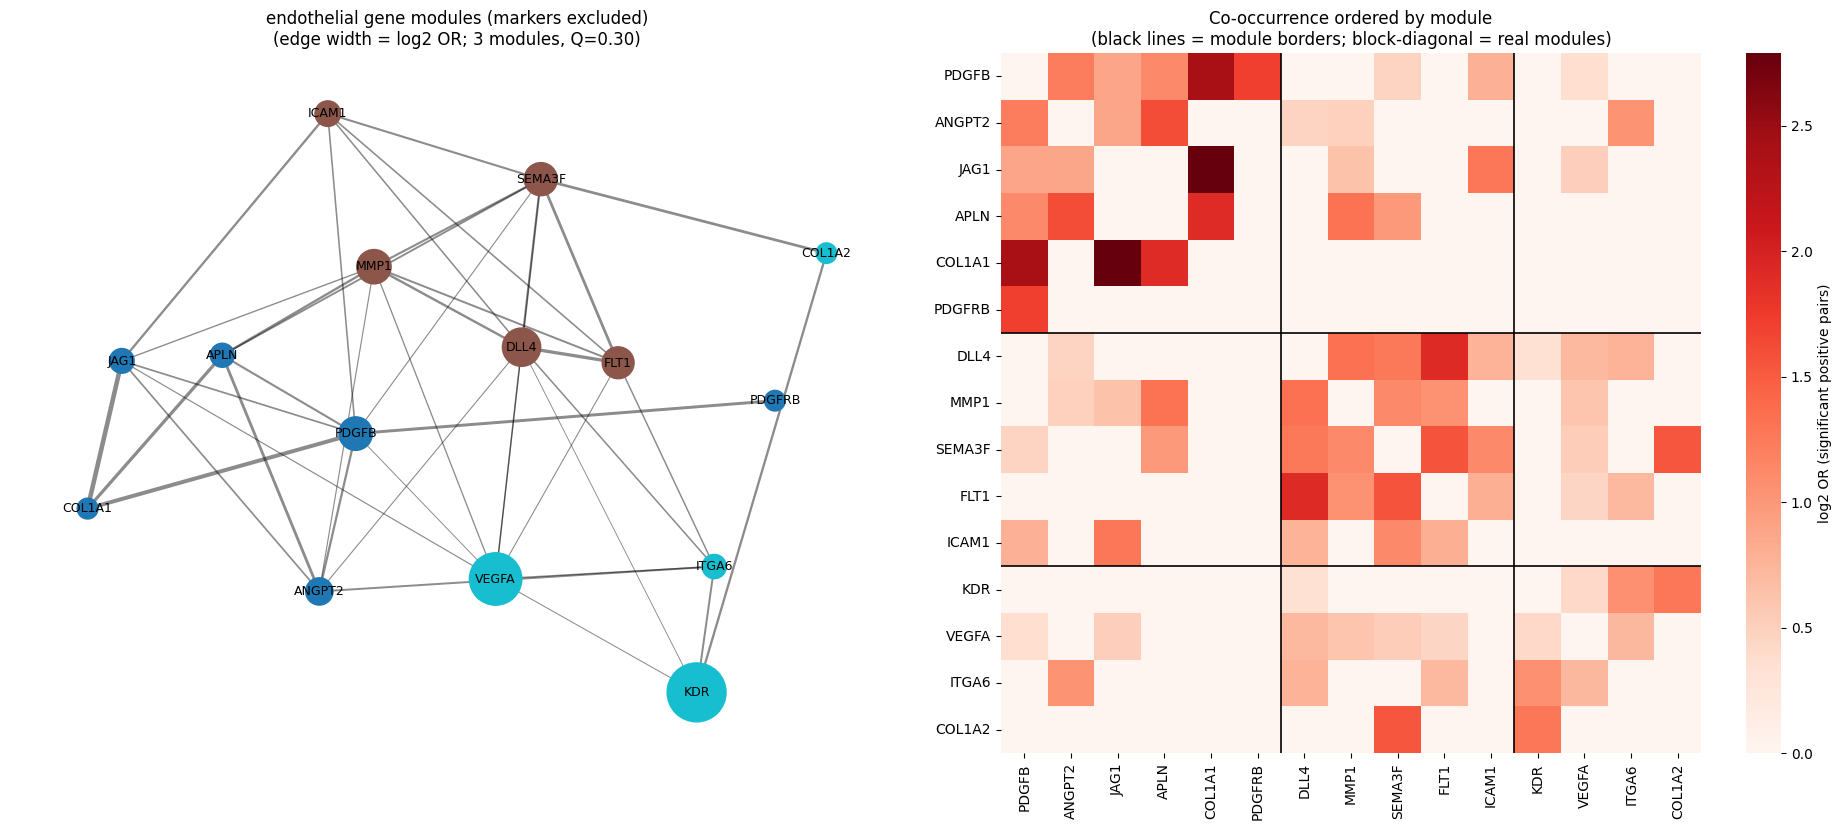

Markers excluded from modules (lineage-defining only): CDH5, PECAM1, VWF
Co-firing gene modules (genes ordered by abundance):
  module 0: PDGFB, ANGPT2, JAG1, APLN, COL1A1, PDGFRB
  module 1: DLL4, MMP1, SEMA3F, FLT1, ICAM1
  module 2: KDR, VEGFA, ITGA6, COL1A2


In [ ]:
# ==========================================================================
# GENE-INTERACTION MODULES. Nodes = genes; an edge joins two genes switched ON TOGETHER
# more than chance (positive co-occurrence, Fisher's exact FDR<0.05, each gene ON in
# >= MIN_ON cells) in the ENDOTHELIAL population. Edge WEIGHT / width = log2 odds ratio
# (EFFECT SIZE, not significance - so widths actually vary). Community detection groups
# co-firing genes into MODULES; we report the modularity Q and a resolution sweep so the
# module structure is QUANTIFIED, and an ordered co-occurrence heatmap so it can be
# eyeballed (real modules = a block-diagonal pattern, not a hairball).
# ==========================================================================

import networkx as nx

MODULE_LINEAGE = "endothelial"     # dominant population
MIN_ON = 20                        # each gene ON in >= this many cells (stable odds ratio)
# Pan-endothelial markers define the lineage but are ON almost everywhere, so they add no
# module structure - drop them and build modules from the functional/programme genes only.
MODULE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1"}
MODULE_GENES = [g for g in GENES if g not in MODULE_MARKER_EXCLUDE]

B = df[(df["cell_type"] == MODULE_LINEAGE) & df["had_reads"]][MODULE_GENES].to_numpy()
on_count = B.sum(0)
on_freq = B.mean(0)

rows = []
for i in range(len(MODULE_GENES)):
    for j in range(i + 1, len(MODULE_GENES)):
        a = int(((B[:, i] == 1) & (B[:, j] == 1)).sum())      # both on
        b = int(on_count[i]) - a
        c = int(on_count[j]) - a
        d = len(B) - a - b - c
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        _, p = fisher_exact([[a, b], [c, d]])
        rows.append((MODULE_GENES[i], MODULE_GENES[j], np.log2(odds), p, int(on_count[i]), int(on_count[j])))
gp = pd.DataFrame(rows, columns=["g1", "g2", "log2_OR", "pvalue", "n1", "n2"])
gp["FDR"] = multipletests(gp.pvalue, method="fdr_bh")[1]

# Edges = significant positive pairs; weight = log2 OR (effect size).
pos = gp[(gp.log2_OR > 0) & (gp.FDR < 0.05) & (gp.n1 >= MIN_ON) & (gp.n2 >= MIN_ON)].copy()
Ggene = nx.Graph()
Ggene.add_nodes_from(MODULE_GENES)
for r in pos.itertuples():
    Ggene.add_edge(r.g1, r.g2, weight=r.log2_OR)

# Community detection + HOW GOOD the split is (modularity Q; >~0.3 = clear modules).
communities = list(nx.community.greedy_modularity_communities(Ggene, weight="weight"))
module_of = {g: m for m, com in enumerate(communities) for g in com}
n_mod = len(communities)
Q = nx.community.modularity(Ggene, communities, weight="weight")

# Robustness: sweep the Louvain resolution (higher -> more, smaller modules).
print("Resolution sweep (Louvain) - is the module count stable?")
for gamma in [0.5, 0.75, 1.0, 1.5, 2.0]:
    com_g = nx.community.louvain_communities(Ggene, weight="weight", resolution=gamma, seed=0)
    print(f"  resolution={gamma:>4}: {len(com_g)} modules, "
          f"Q={nx.community.modularity(Ggene, com_g, weight='weight'):.3f}")
print(f"\nChosen (greedy) partition: {n_mod} modules, modularity Q = {Q:.3f}  "
      f"(Q ~0 = one interconnected hairball; Q >~0.3 = genuinely modular)\n")

# --- Figure 1: the graph, edge WIDTH = log2 OR (effect size) ---
module_cmap = plt.get_cmap("tab10", max(n_mod, 1))
connected = [g for g in Ggene.nodes() if Ggene.degree(g) > 0]
H = Ggene.subgraph(connected)
layout = nx.spring_layout(H, weight="weight", k=1.4, seed=1)
node_size = [200 + 1600 * on_freq[MODULE_GENES.index(g)] / on_freq.max() for g in H.nodes()]
node_color = [module_cmap(module_of[g]) for g in H.nodes()]
ew = np.array([H[u][v]["weight"] for u, v in H.edges()])
edge_width = 0.3 + 3.0 * ew / ew.max()

fig, axg = plt.subplots(1, 2, figsize=(19, 8))
nx.draw_networkx_edges(H, layout, ax=axg[0], width=edge_width, alpha=0.45)
nx.draw_networkx_nodes(H, layout, ax=axg[0], node_size=node_size, node_color=node_color)
nx.draw_networkx_labels(H, layout, ax=axg[0], font_size=9)
axg[0].set_title(f"{MODULE_LINEAGE} gene modules (markers excluded)\n(edge width = log2 OR; {n_mod} modules, Q={Q:.2f})")
axg[0].axis("off")

# --- Figure 2: co-occurrence matrix ORDERED BY MODULE. Real modules = block-diagonal. ---
order = [g for com in communities for g in sorted(com, key=lambda x: -on_freq[MODULE_GENES.index(x)])]
M = pd.DataFrame(0.0, index=order, columns=order)
for r in pos.itertuples():
    M.loc[r.g1, r.g2] = r.log2_OR
    M.loc[r.g2, r.g1] = r.log2_OR
sns.heatmap(M, cmap="Reds", square=True, ax=axg[1],
            cbar_kws={"label": "log2 OR (significant positive pairs)"})
for bnd in np.cumsum([len(c) for c in communities])[:-1]:
    axg[1].axhline(bnd, color="k", lw=1.2); axg[1].axvline(bnd, color="k", lw=1.2)
axg[1].set_title("Co-occurrence ordered by module\n(black lines = module borders; block-diagonal = real modules)")
plt.tight_layout(); plt.show()

print(f"Markers excluded from modules (lineage-defining only): {', '.join(sorted(MODULE_MARKER_EXCLUDE))}")
print("Co-firing gene modules (genes ordered by abundance):")
for m, com in enumerate(communities):
    ordered = sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)])
    print(f"  module {m}: {', '.join(ordered)}")
isolated = [g for g in MODULE_GENES if Ggene.degree(g) == 0]
if isolated:
    print(f"  no significant positive partner: {', '.join(isolated)}")

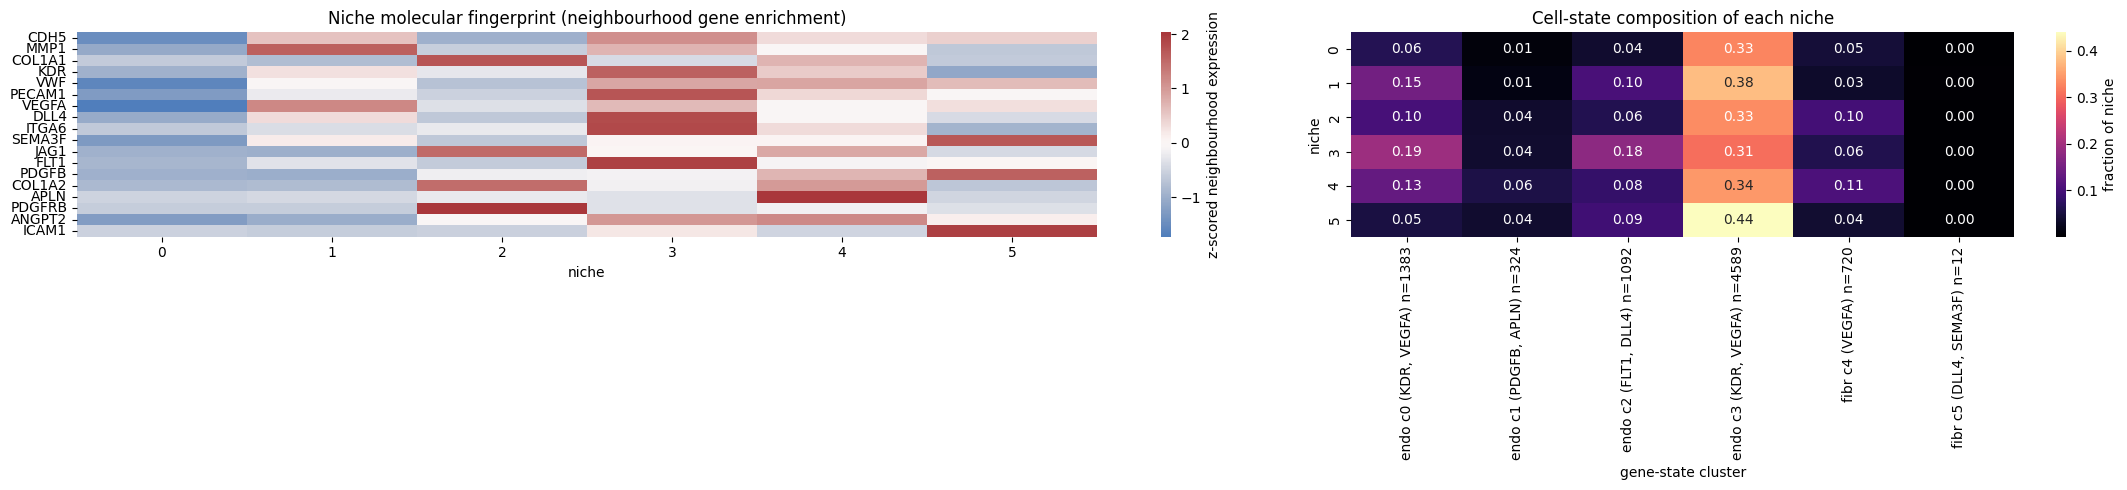

Niche fingerprints (top enriched neighbourhood genes):
  niche 0 (n=4,589): APLN, ICAM1, PDGFRB, COL1A1
  niche 1 (n=2,476): MMP1, VEGFA, CDH5, DLL4
  niche 2 (n=1,311): PDGFRB, COL1A1, JAG1, COL1A2
  niche 3 (n=1,839): FLT1, ITGA6, DLL4, PECAM1
  niche 4 (n=1,061): APLN, ANGPT2, COL1A2, VWF
  niche 5 (n=1,771): ICAM1, SEMA3F, PDGFB, VWF


In [72]:
# WHAT DEFINES EACH NICHE?
#  (left)  z-scored mean neighbourhood gene expression -> the molecular signature of each
#          niche (which genes are enriched among a cell's neighbours in that niche).
#  (right) gene-state cluster composition -> which cell states build each niche.
nb_gene_cols = [f"nb_{g}" for g in GENES]
niche_gene = df.groupby("niche")[nb_gene_cols].mean()
niche_gene_z = (niche_gene - niche_gene.mean()) / (niche_gene.std() + 1e-9)
niche_gene_z.columns = GENES

state_comp = pd.crosstab(df["niche"], df["bmm"], normalize="index").drop(columns=[-1], errors="ignore")
state_comp.columns = [cluster_name_of.get(c, str(c)) for c in state_comp.columns]

fig, axes = plt.subplots(1, 2, figsize=(22, 5), gridspec_kw={"width_ratios": [2, 1.3]})
sns.heatmap(niche_gene_z.T, cmap="vlag", center=0, ax=axes[0],
            cbar_kws={"label": "z-scored neighbourhood expression"})
axes[0].set_title("Niche molecular fingerprint (neighbourhood gene enrichment)")
axes[0].set_xlabel("niche")
sns.heatmap(state_comp, cmap="magma", annot=True, fmt=".2f", ax=axes[1],
            cbar_kws={"label": "fraction of niche"})
axes[1].set_title("Cell-state composition of each niche")
axes[1].set_xlabel("gene-state cluster"); axes[1].set_ylabel("niche")
plt.tight_layout(); plt.show()

print("Niche fingerprints (top enriched neighbourhood genes):")
for niche_id in niche_gene_z.index:
    top = niche_gene_z.loc[niche_id].sort_values(ascending=False).head(4).index.tolist()
    print(f"  niche {niche_id} (n={int((df['niche'] == niche_id).sum()):,}): {', '.join(top)}")

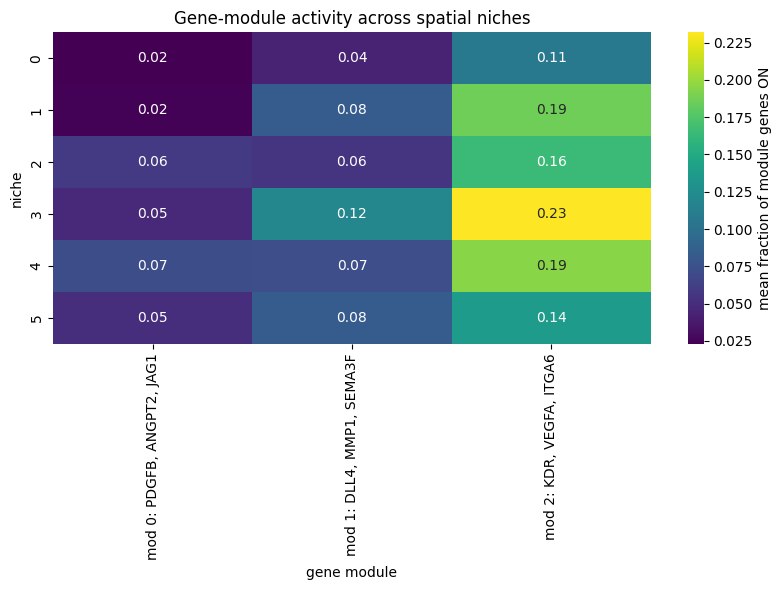

In [79]:
# GENE-MODULE ACTIVITY PER NICHE. For every cell, the fraction of each module's genes
# that are ON; averaged per niche -> which co-firing gene programmes are active where.
module_labels = {m: f"mod {m}: {', '.join(sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)])[:3])}"
                 for m, com in enumerate(communities)}
module_activity = pd.DataFrame(
    {module_labels[m]: df[list(com)].mean(axis=1) for m, com in enumerate(communities)})
module_activity["niche"] = df["niche"].to_numpy()
niche_module = module_activity.groupby("niche").mean()

plt.figure(figsize=(1.4 * len(communities) + 4, 0.5 * df["niche"].nunique() + 3))
sns.heatmap(niche_module, cmap="viridis", annot=True, fmt=".2f",
            cbar_kws={"label": "mean fraction of module genes ON"})
plt.title("Gene-module activity across spatial niches")
plt.xlabel("gene module"); plt.ylabel("niche")
plt.tight_layout(); plt.show()

In [84]:
# ==========================================================================
# IS STATE c1 (APLN/PDGFB sprout) SPATIALLY CLOSE TO PERICYTES?
# Pericyte/mural marker in this panel = PDGFRB. c1 expresses PDGFB, the ligand tip cells
# use to RECRUIT pericytes, so it should sit nearer PDGFRB+ cells than other endothelial
# states. Three independent tests, all restricted to within-image neighbours.
# ==========================================================================
from scipy.stats import mannwhitneyu

endo = df[(df.cell_type == "endothelial") & df.had_reads & (df.bmm >= 0)].copy()
endo_ids = sorted(endo.bmm.unique())
name = {b: cluster_name_of.get(b, str(b)) for b in endo_ids}
c1 = max(endo_ids, key=lambda b: df.loc[df.bmm == b, "APLN"].mean())   # the APLN/PDGFB state
print(f"c1 (APLN/PDGFB sprout) = {name[c1]}\n")

# (1) Fraction of each cell's 15 nearest neighbours that are PDGFRB+ (mural), per endo state.
tab = endo.groupby("bmm")["nb_PDGFRB"].mean().rename(index=name).sort_values(ascending=False)
print("Mean neighbourhood PDGFRB (fraction of 15 neighbours that are PDGFRB+):")
print(tab.round(3), "\n")
p1 = mannwhitneyu(endo.loc[endo.bmm == c1, "nb_PDGFRB"],
                  endo.loc[endo.bmm != c1, "nb_PDGFRB"], alternative="greater").pvalue
print(f"  c1 neighbourhood more PDGFRB+ than other endothelial states? p = {p1:.2e}\n")

# (2) Distance from each endothelial cell to the NEAREST PDGFRB+ cell (same image).
dist = np.full(len(df), np.nan)
for _, sub in df.groupby(IMAGE_KEY):
    peri = sub[sub["PDGFRB"] == 1]
    src = sub[sub["PDGFRB"] == 0]
    if len(peri) and len(src):
        dd, _ = cKDTree(peri[["x_um", "y_um", "z_um"]].to_numpy()).query(
            src[["x_um", "y_um", "z_um"]].to_numpy(), k=1)
        dist[src.index.to_numpy()] = dd
df["dist_to_PDGFRB_um"] = dist
ed = df[(df.cell_type == "endothelial") & df.had_reads & (df.bmm >= 0) & (df["PDGFRB"] == 0)]
print("Median distance (um) from endothelial cell to nearest PDGFRB+ cell, per state:")
print(ed.groupby("bmm")["dist_to_PDGFRB_um"].median().rename(index=name).sort_values(), "\n")
p2 = mannwhitneyu(ed.loc[ed.bmm == c1, "dist_to_PDGFRB_um"].dropna(),
                  ed.loc[ed.bmm != c1, "dist_to_PDGFRB_um"].dropna(), alternative="less").pvalue
print(f"  c1 closer to PDGFRB+ cells than other endothelial states? p = {p2:.2e}\n")

# (3) Permutation-test neighbour-enrichment z between c1 and the mural/fibroblast (PDGFRB+) clusters.
fibro_cols = [c for c in z_all.columns if c.startswith("fibr")]
print("Neighbour-enrichment z (from z_all) between c1 and the PDGFRB+ mural/fibroblast clusters:")
print(z_all.loc[name[c1], fibro_cols].round(2))

c1 (APLN/PDGFB sprout) = endo c1 (PDGFB, APLN) n=324

Mean neighbourhood PDGFRB (fraction of 15 neighbours that are PDGFRB+):
bmm
endo c1 (PDGFB, APLN) n=324    0.027
endo c2 (FLT1, DLL4) n=1092    0.017
endo c0 (KDR, VEGFA) n=1383    0.017
endo c3 (KDR, VEGFA) n=4589    0.016
Name: nb_PDGFRB, dtype: float64 

  c1 neighbourhood more PDGFRB+ than other endothelial states? p = 2.11e-08

Median distance (um) from endothelial cell to nearest PDGFRB+ cell, per state:
bmm
endo c1 (PDGFB, APLN) n=324     79.085700
endo c2 (FLT1, DLL4) n=1092    112.387409
endo c3 (KDR, VEGFA) n=4589    115.938256
endo c0 (KDR, VEGFA) n=1383    118.230765
Name: dist_to_PDGFRB_um, dtype: float64 

  c1 closer to PDGFRB+ cells than other endothelial states? p = 1.35e-16

Neighbour-enrichment z (from z_all) between c1 and the PDGFRB+ mural/fibroblast clusters:
fibr c4 (VEGFA) n=720          0.62
fibr c5 (DLL4, SEMA3F) n=12   -0.91
Name: endo c1 (PDGFB, APLN) n=324, dtype: float64


Image -> timepoint mapping:
  6h     <- dev4_1_6h
  6h     <- dev4_2_6h
  6h     <- dev4_3_6h
  day1   <- dev7_2_day1
  day1   <- dev7_3_day1
  day1   <- dev7_3_day1_large
  day2   <- dev10_1_day2
  day2   <- dev10_3_day2
  day2   <- dev10_4_day2
  day4   <- dev10_2_day4
  day4   <- dev10_4_day4
  day4   <- dev9_4_day4

Cells per timepoint:
timepoint
6h      3513
day1    4285
day2    2611
day4    2638
Name: count, dtype: int64 

Gene-state cluster proportion by timepoint:
 cluster    endo c0 (KDR, VEGFA) n=1383  endo c1 (PDGFB, APLN) n=324  \
timepoint                                                             
6h                               0.059                        0.041   
day1                             0.200                        0.026   
day2                             0.245                        0.054   
day4                             0.173                        0.045   

cluster    endo c2 (FLT1, DLL4) n=1092  endo c3 (KDR, VEGFA) n=4589  \
timepoint               

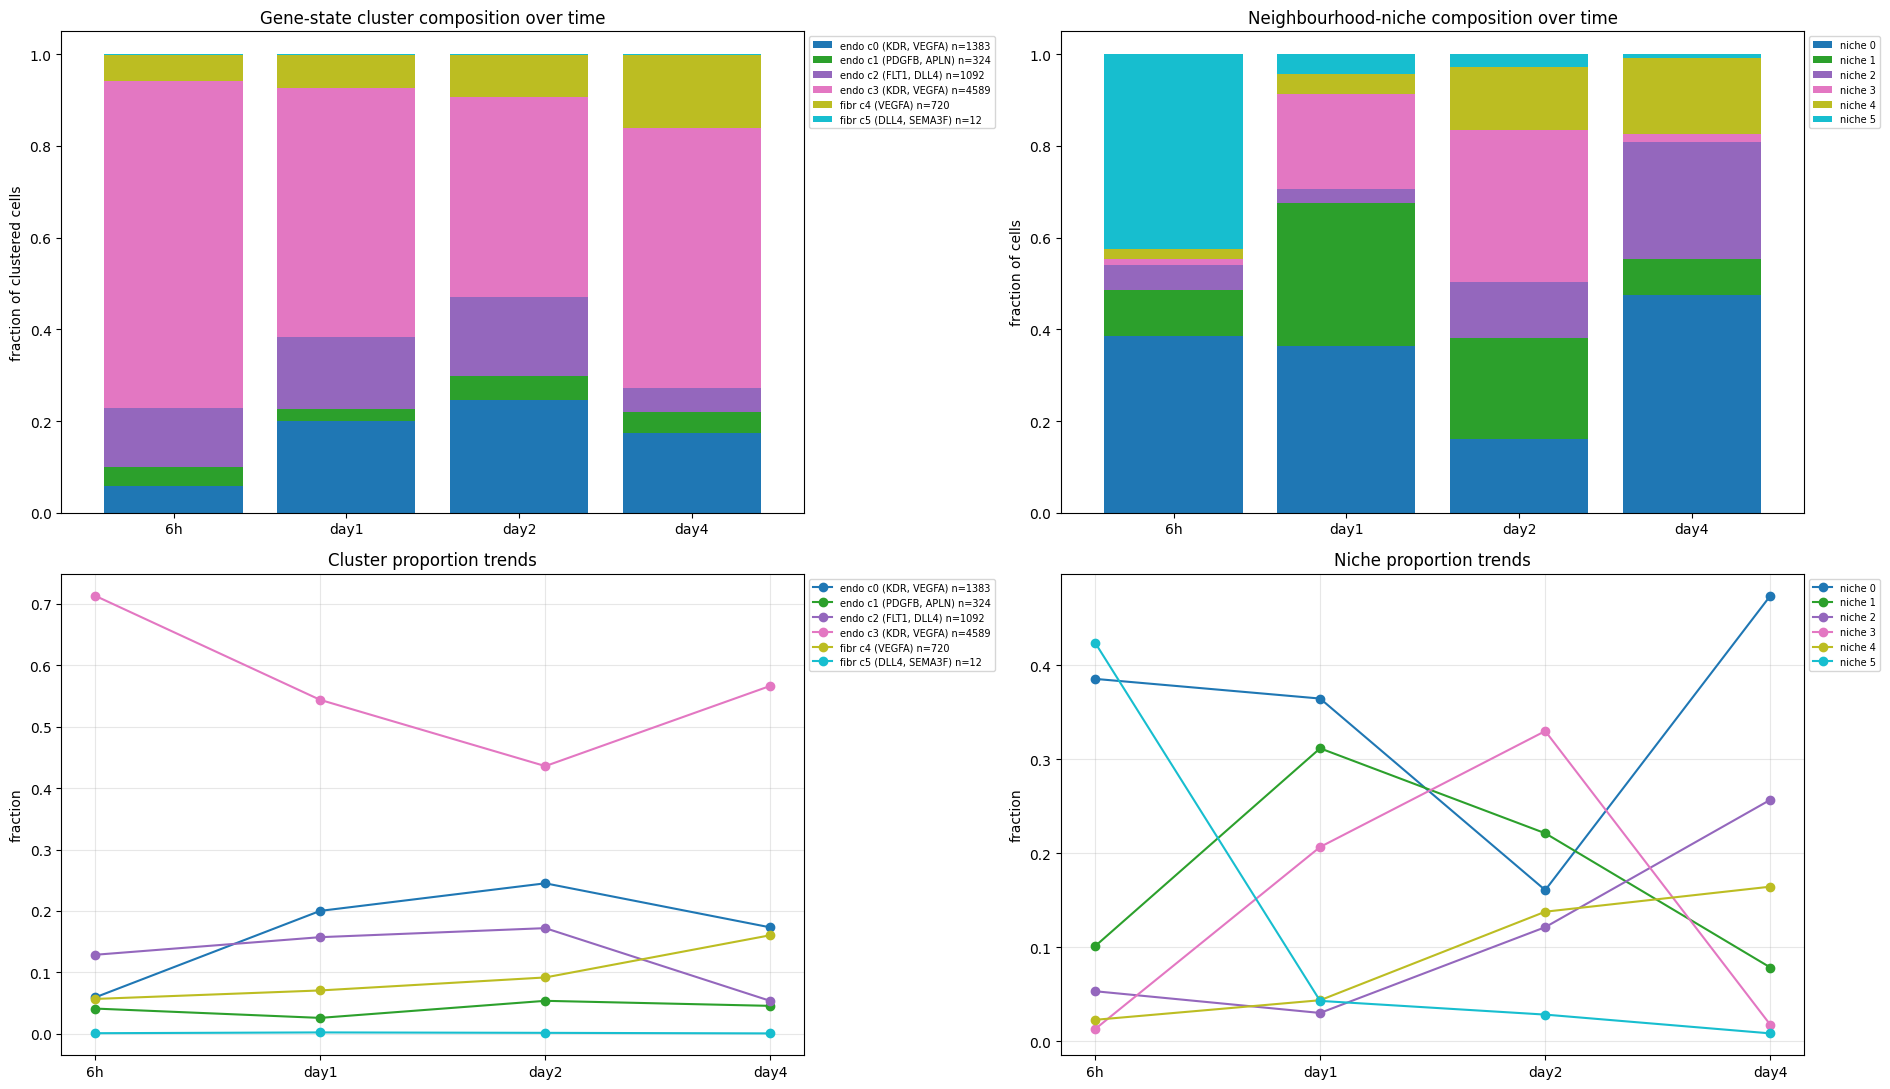

In [86]:
# ==========================================================================
# HOW DO GENE-STATE CLUSTER / NICHE PROPORTIONS CHANGE OVER TIME?
# Timepoint is encoded in the image name (source_folder): 6h -> day1 -> day2 -> day4.
# CAVEAT: each timepoint is a different sample/device (biological-replicate confound), so
# read these as descriptive trends, not statistically powered change.
# ==========================================================================
import re

TIME_ORDER = ["6h", "day1", "day2", "day4"]

def _timepoint(name):
    s = str(name).lower().replace(" ", "")
    if "6h" in s:                                  return "6h"
    if "day4" in s or re.search(r"d4(?!\d)", s):   return "day4"
    if "day2" in s or re.search(r"d2(?!\d)", s):   return "day2"
    if "day1" in s or re.search(r"d1(?!\d)", s):   return "day1"
    return "unknown"

df["timepoint"] = pd.Categorical(df[IMAGE_KEY].map(_timepoint),
                                 categories=TIME_ORDER + ["unknown"], ordered=True)

print("Image -> timepoint mapping:")
for img, tp in sorted(df.groupby(IMAGE_KEY)["timepoint"].first().items(), key=lambda kv: str(kv[1])):
    print(f"  {str(tp):6} <- {img}")
print("\nCells per timepoint:")
print(df["timepoint"].value_counts().reindex(TIME_ORDER), "\n")

tp_valid = [t for t in TIME_ORDER if (df["timepoint"] == t).any()]

# Proportions per timepoint (each column sums to 1 within a timepoint).
clus = df[df["bmm"] >= 0].copy()
clus["cluster"] = clus["bmm"].map(cluster_name_of)
clus_prop = pd.crosstab(clus["timepoint"], clus["cluster"], normalize="index").reindex(tp_valid)
clus_prop = clus_prop[[c for c in cluster_names if c in clus_prop.columns]]
niche_prop = pd.crosstab(df["timepoint"], df["niche"], normalize="index").reindex(tp_valid)

print("Gene-state cluster proportion by timepoint:\n", clus_prop.round(3), "\n")
print("Niche proportion by timepoint:\n", niche_prop.round(3))

fig, ax = plt.subplots(2, 2, figsize=(19, 11))
# Row 0: stacked-bar composition. Row 1: per-group line trends.
clus_colors = [cluster_palette[c] for c in clus_prop.columns]
niche_colors = [niche_color[n] for n in niche_prop.columns]

clus_prop.plot(kind="bar", stacked=True, ax=ax[0, 0], color=clus_colors, width=0.8)
ax[0, 0].set(title="Gene-state cluster composition over time", ylabel="fraction of clustered cells", xlabel="")
ax[0, 0].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax[0, 0].tick_params(axis="x", rotation=0)

niche_prop.plot(kind="bar", stacked=True, ax=ax[0, 1], color=niche_colors, width=0.8)
ax[0, 1].set(title="Neighbourhood-niche composition over time", ylabel="fraction of cells", xlabel="")
ax[0, 1].legend([f"niche {n}" for n in niche_prop.columns], fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax[0, 1].tick_params(axis="x", rotation=0)

for c, col in zip(clus_prop.columns, clus_colors):
    ax[1, 0].plot(range(len(tp_valid)), clus_prop[c].values, "o-", color=col, label=c)
ax[1, 0].set(title="Cluster proportion trends", ylabel="fraction", xticks=range(len(tp_valid)))
ax[1, 0].set_xticklabels(tp_valid); ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")

for n, col in zip(niche_prop.columns, niche_colors):
    ax[1, 1].plot(range(len(tp_valid)), niche_prop[n].values, "o-", color=col, label=f"niche {n}")
ax[1, 1].set(title="Niche proportion trends", ylabel="fraction", xticks=range(len(tp_valid)))
ax[1, 1].set_xticklabels(tp_valid); ax[1, 1].grid(alpha=0.3)
ax[1, 1].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")

plt.tight_layout(); plt.show()

### Conclusions - gene modules

**Approach.** A gene-gene graph from significant **positive** co-occurrences in endothelial
cells. Edge weight = **log2 odds ratio (effect size)**, so edge width reflects *how much* two
genes co-fire, not just significance. The three **pan-endothelial marker genes** (`CDH5`,
`VWF`, `PECAM1`) are **excluded** here - they define the lineage but are ON almost everywhere,
so they carry no module information. Communities on the remaining functional genes = co-firing
**modules**; module activity is then averaged per niche.

**How real are the modules? (quantified, not eyeballed).** With the markers removed the
structure *sharpens*: the greedy partition gives **3 modules at modularity Q = 0.30** - right
at the usual Q > ~0.3 "genuinely modular" threshold (dropping the ubiquitous markers raised Q
from ~0.26). The Louvain **resolution sweep is also more stable**: a robust **2-module** split
holds from low resolution up to resolution 1 (Q=0.30), splitting further into 4-6 only at high
resolution. So there is a solid two-block backbone that resolves into three interpretable
modules; the finer boundaries beyond that are still resolution-dependent, so don't over-read
them.

**Assumptions / drawbacks.** Co-occurrence is association, not causal regulation. Only positive
edges are used; the finer partition depends on the resolution parameter (shown above); and this
is built on endothelial cells only (the dominant lineage).

**Biology - three co-firing modules:**
- **Angiogenic core** - `KDR`, `VEGFA`, `ITGA6` (+`COL1A2`): the VEGF-activation programme.
- **Tip / sprouting** - `DLL4`, `MMP1`, `SEMA3F`, `FLT1`, `ICAM1`: Notch tip-selection +
  ECM-remodelling/guidance genes.
- **Mature-vessel / mural-remodelling** - `PDGFB`, `ANGPT2`, `JAG1`, `APLN`, `COL1A1`,
  `PDGFRB`: vessel destabilisation, pericyte recruitment and collagen/mural genes.

**Do the methods agree?** Yes. These three modules map directly onto the Bernoulli endothelial
states (`KDR`/`VEGFA` core = c0; `DLL4`/`FLT1`/`MMP1` tip = c2) and the angiogenic vs mural
niches. All three views (gene states, gene modules, spatial niches) converge on the **same 2-3
endothelial programmes**, and with the markers dropped the module view is now a genuinely
modular (Q~0.30) corroboration rather than the softest of the three.

---

## Overall biological conclusion

The sample is a **majority-endothelial vascular bed** (~7.4k endothelial vs ~0.7k
fibroblast cells with reads) with a minor, discrete fibroblast population. Endothelial cells
are **not discrete cell types but a continuum** on a shared `CDH5` (VE-cadherin) backbone,
structured by a small number of overlapping programmes.

### Marker glossary (what the genes mean here)

| Gene | Role | Programme it marks |
|---|---|---|
| `CDH5` (VE-cadherin) | pan-endothelial junctional identity | backbone (all endothelium) |
| `KDR` (VEGFR2) | main pro-angiogenic VEGF receptor | **angiogenic core** |
| `VEGFA` | pro-angiogenic ligand (auto/paracrine) | **angiogenic core** |
| `ITGA6` | laminin integrin, migration / basement membrane | angiogenic core |
| `DLL4` | Notch ligand, **tip-cell selection** | **tip / sprouting** |
| `FLT1` (VEGFR1) | VEGF decoy receptor, tip/stalk balance | **tip / sprouting** |
| `MMP1` | matrix metalloprotease, ECM breakdown for sprouting | **tip / sprouting** |
| `SEMA3F` | semaphorin guidance cue | tip / sprouting |
| `ICAM1` | endothelial activation / adhesion | tip / sprouting (activated) |
| `APLN` (apelin) | classic **tip-cell** marker | sprouting front |
| `PDGFB` | pericyte-recruitment signal from tip cells | sprouting -> mural |
| `ANGPT2` | Tie2 ligand, vessel destabilisation / remodelling | mature-vessel / remodelling |
| `VWF`, `PECAM1` | mature/large-vessel endothelial markers | mature vessel |
| `JAG1` | Notch ligand (stalk / mural) | mature-vessel / mural |
| `PDGFRB`, `COL1A1/2` | mural / fibroblast markers | non-angiogenic stroma |

### The endothelial gene-state clusters (Section 2, markers `CDH5`/`VWF`/`PECAM1` excluded from the clustering)

| State | n (%) | Defining markers (upregulated) | Spatial cohesion z | What it is | Angiogenic? |
|---|---|---|---|---|---|
| **c3 - quiescent backbone** | 4,589 (62%) | `CDH5` only, low `KDR` | +4.5 (mostly diffuse) | resting / phalanx endothelium | **no** |
| **c0 - VEGF-activated** | 1,383 (19%) | `KDR` + `VEGFA` | +6.6 | canonical angiogenic activation | **YES (core)** |
| **c2 - tip / sprouting** | 1,092 (15%) | `FLT1` + `DLL4` (+`VEGFA`) | **+9.3 (strongest patches)** | sprouting tip / stalk front | **YES (tip)** |
| **c1 - apelin / PDGFB sprout** | 324 (4%) | `APLN` + `PDGFB` (+`VEGFA`/`DLL4`) | +5.9 | apelin+ tip-like, pericyte-recruiting | **YES (tip-associated)** |

So the **angiogenic states are c0, c2 and c1**:
- **c0** is the *core VEGF-driven angiogenic* state - `KDR`(VEGFR2) receiving `VEGFA` on the
  `CDH5` backbone. This is the main axis of the whole endothelial continuum (it is also
  logistic-PCA axis 1: `KDR`+`VEGFA` vs the plain `CDH5` core).
- **c2** is the *tip / sprouting* state - `DLL4`+`FLT1`(+`MMP1`), i.e. Notch-driven tip
  selection plus ECM-remodelling for sprout invasion. It forms the **tightest spatial
  patches (z = +9.3)**, consistent with sprouting fronts being physically clustered.
- **c1** is a smaller *apelin/PDGFB* sprouting-associated state (`APLN` is a textbook
  tip-cell marker; `PDGFB` recruits pericytes) - a tip-to-mural transition flavour.
- **c3** (the 62% majority) is **not** angiogenic - it is `CDH5`-only quiescent endothelium,
  and it is spatially **diffuse** (z only +4.5), i.e. a shared baseline rather than a
  discrete patchy state.

### The same angiogenic signal in the other two views

- **Gene modules (Section 4).** With the pan-endothelial markers (`CDH5`, `VWF`, `PECAM1`)
  dropped, the co-occurrence graph resolves into **three genuinely modular blocks**
  (modularity Q~0.30): an **angiogenic core** (`KDR`, `VEGFA`, `ITGA6`, `COL1A2`), a
  **tip/sprouting** module (`DLL4`, `MMP1`, `SEMA3F`, `FLT1`, `ICAM1` - the genes defining
  states c0 and c2), and a **mature/mural-remodelling** module (`PDGFB`, `ANGPT2`, `JAG1`,
  `APLN`, `COL1A1`, `PDGFRB`). A robust 2-block split underlies these up to resolution 1, so
  this view now *corroborates* the state/niche programmes as an independent modular partition.
- **Spatial niches (Section 3).** The angiogenic niches are **niche 1** (`MMP1`/`VEGFA`/
  `DLL4` - a proteolytic-angiogenic front), **niche 3** (`FLT1`/`ITGA6`/`DLL4` - the
  tip/sprouting niche), and **niche 5** (`ICAM1`/`SEMA3F`/`PDGFB` - activated/guidance),
  with **niche 4** (`APLN`/`ANGPT2`) a remodelling flavour. Niche 2 (`PDGFRB`/`COL1A1`/
  `JAG1`) is mural/fibroblast and niche 0 is low-signal quiescent - the non-angiogenic
  environments.

**Bottom line.** The `KDR`/`VEGFA` **angiogenic activation** axis (state c0) and the
`DLL4`/`FLT1`/`MMP1` **tip/sprouting** axis (state c2) are the two angiogenic programmes, and
they recur as gene-state clusters, gene modules, and spatial niches - and form real spatial
patches. The bulk `CDH5`-only endothelium is quiescent and diffuse, and fibroblasts
(`PDGFRB`/collagen) are few, discrete, and spatially segregated from the angiogenic
endothelium.

**Caveats to keep in mind:** the gene-module partition is only **modestly modular** (Q~0.30,
and finer splits are resolution-dependent) - the three-module structure is clear but the exact
boundaries beyond the two-block backbone should not be over-read; all-0-read cells were
assigned lineages artificially and carry no state; co-occurrence and spatial adjacency are
associations, not proof of interaction or regulation; very small clusters (e.g. c1 n=324, or
the n~12 fibroblast state) and the chosen k / niche-count are not robust; marker identities
above are the conventional vascular-biology readings of these genes, not validated here; and
this is a single replicate.

# Step-by-step results write-up

A narrative walk-through of the key results with the figures embedded. **Run the code cell
directly below first** - it regenerates the key figures from the analysis above and saves
them to `report_figures/`, which the write-up then embeds.

In [80]:
# ==========================================================================
# SAVE KEY REPORT FIGURES for the write-up below - regenerated compactly from variables
# already in memory and written to report_figures/ (embedded by the markdown that follows).
# ==========================================================================
from matplotlib.colors import BoundaryNorm

fig_dir = output_dir / "report_figures"
fig_dir.mkdir(exist_ok=True)

# 1) Endothelial continuum diagnostics: confidence hist + logistic-PCA curve + latent scatter.
r = res_endo_all
K = r["K"]; mr = r["max_resp"]; de = r["dev_explained"]; sc = r["lpca_scores"]; lab = r["bmm_labels"]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].hist(mr, bins=30, range=(1 / K, 1), color="steelblue"); ax[0].axvline(0.8, color="red", ls="--")
ax[0].set(title=f"Endothelial assignment confidence\n({100 * np.mean(mr >= 0.8):.0f}% cells >=0.8 -> continuum)",
          xlabel="max responsibility per cell", ylabel="cells")
ks = list(de); ax[1].plot(ks, [100 * de[k] for k in ks], "o-"); ax[1].grid(alpha=.3)
ax[1].set(title="Logistic PCA: no early plateau -> many small axes", ylim=(0, 100),
          xlabel="# latent axes", ylabel="% deviance explained")
cmap = plt.get_cmap("tab10", K); norm = BoundaryNorm(np.arange(-.5, K + .5, 1), K)
s = ax[2].scatter(sc[:, 0], sc[:, 1], c=lab, cmap=cmap, norm=norm, s=8, alpha=.6)
ax[2].set(title="Cells on latent axes (colour = Bernoulli state)", xlabel="axis 1", ylabel="axis 2")
plt.colorbar(s, ax=ax[2], ticks=range(K), label="state")
plt.tight_layout(); plt.savefig(fig_dir / "fig1_continuum.png", dpi=110, bbox_inches="tight"); plt.close()

# 2) Gene-state cluster spatial co-location (z_all from the all-cells permutation test).
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(z_all, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True, ax=ax,
            cbar_kws={"label": "neighbour-enrichment z"})
ax.set_title("Do gene-state clusters co-locate? (within-image permutation z)")
plt.tight_layout(); plt.savefig(fig_dir / "fig2_spatial.png", dpi=110, bbox_inches="tight"); plt.close()

# 3) Niche molecular fingerprint + cell-state composition.
fig, ax = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={"width_ratios": [2, 1.3]})
sns.heatmap(niche_gene_z.T, cmap="vlag", center=0, ax=ax[0], cbar_kws={"label": "z neighbourhood expr"})
ax[0].set_title("Niche molecular fingerprint"); ax[0].set_xlabel("niche")
sns.heatmap(state_comp, cmap="magma", annot=True, fmt=".2f", ax=ax[1], cbar_kws={"label": "fraction"})
ax[1].set_title("Cell-state composition of each niche"); ax[1].set_xlabel("state"); ax[1].set_ylabel("niche")
plt.tight_layout(); plt.savefig(fig_dir / "fig3_niches.png", dpi=110, bbox_inches="tight"); plt.close()

# 4) Gene-interaction module graph.
_conn = [g for g in Ggene.nodes() if Ggene.degree(g) > 0]
Hs = Ggene.subgraph(_conn)
lay = nx.spring_layout(Hs, weight="weight", k=1.4, seed=1)
mcmap = plt.get_cmap("tab10", max(len(communities), 1))
nsz = [200 + 1600 * on_freq[MODULE_GENES.index(g)] / on_freq.max() for g in Hs.nodes()]
ncol = [mcmap(module_of[g]) for g in Hs.nodes()]
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(Hs, lay, ax=ax, alpha=.35)
nx.draw_networkx_nodes(Hs, lay, ax=ax, node_size=nsz, node_color=ncol)
nx.draw_networkx_labels(Hs, lay, ax=ax, font_size=9)
ax.set_title("Endothelial gene-interaction modules (positive co-occurrence)"); ax.axis("off")
plt.tight_layout(); plt.savefig(fig_dir / "fig4_modules.png", dpi=110, bbox_inches="tight"); plt.close()

# 5) Gene-module activity per niche.
fig, ax = plt.subplots(figsize=(1.4 * len(communities) + 4, 0.5 * len(niche_module) + 3))
sns.heatmap(niche_module, cmap="viridis", annot=True, fmt=".2f", ax=ax,
            cbar_kws={"label": "mean fraction of module genes ON"})
ax.set_title("Gene-module activity across niches"); ax.set_xlabel("module"); ax.set_ylabel("niche")
plt.tight_layout(); plt.savefig(fig_dir / "fig5_module_niche.png", dpi=110, bbox_inches="tight"); plt.close()

print("Saved report figures ->", fig_dir)

Saved report figures -> c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\report_figures


## 1. Are endothelial cells discrete types or a continuum?

Endothelial cells were clustered on their 18-gene on/off profile, with the lineage markers
`CDH5`/`VWF`/`PECAM1` **excluded** so the clusters capture *function*, not identity. We then
probed the result three independent ways.

![Endothelial continuum diagnostics](report_figures/fig1_continuum.png)

- **Left - assignment confidence.** Only ~38% of cells are confidently placed in one state
  (>=0.8); most sit *between* states. A discrete population would pile up against 1.0.
- **Middle - logistic PCA.** The deviance-explained curve keeps climbing with no early
  plateau - no single "dial" captures the cells; they spread along many small axes.
- **Right - cells on the latent axes.** One continuous cloud that the Bernoulli state colours
  merely slice up, rather than separated islands.

**Conclusion:** endothelial cells form a **structured continuum**, whose dominant axis is
`KDR`/`VEGFA` angiogenic activation on the shared `CDH5` backbone. (Run separately,
fibroblasts were 99% confidently sorted into 2 clean states - genuinely **discrete** - so the
continuum is specific to endothelium.)

## 2. Are the gene-state clusters "real" in tissue?

Every cell was labelled with its state, then a within-image label-shuffling permutation test
asked whether cells of the same state sit together more than chance (diagonal) and which
states neighbour which (off-diagonal).

![Gene-state cluster spatial co-location](report_figures/fig2_spatial.png)

- The **angiogenic states are spatially cohesive** - the `KDR`/`VEGFA` state (z ~ +6.6) and
  especially the `FLT1`/`DLL4` tip state (z ~ +9.3, the tightest patches).
- The **`CDH5`-only backbone is spatially diffuse** (z ~ +4.5) - a shared baseline, not a
  discrete patch.
- Collagen fibroblasts sit **apart** from the angiogenic endothelium (negative off-diagonal),
  not intermixed.

**Conclusion:** the *functional* (angiogenic / sprouting) states occupy genuine tissue
territory; the backbone does not.

## 3. What defines the spatial niches?

Niches are recurring neighbourhood micro-environments, built from the neighbourhood
expression of the informative genes only (cell-type composition, entropy and lineage markers
were deliberately excluded, or the niches just track "endothelial-dense vs mixed").

![Niche molecular fingerprint and cell-state composition](report_figures/fig3_niches.png)

Each niche has a distinct molecular signature (left) and cell-state composition (right):
a `MMP1`/`VEGFA` proteolytic-angiogenic niche, a `FLT1`/`DLL4`/`ITGA6` tip/sprouting niche,
an `APLN`/`ANGPT2` remodelling niche, and a `PDGFRB`/`JAG1` mural/fibroblast niche.

## 4. Which genes act together? (gene modules)

A gene-gene graph of significant **positive** co-occurrences (edge weight = `-log10 FDR`) in
endothelial cells; communities are co-firing **modules**.

![Gene-interaction modules](report_figures/fig4_modules.png)

Three modules emerge: an **angiogenic core** (`CDH5`, `KDR`, `VEGFA`, `ITGA6`), a
**tip/sprouting** module (`DLL4`, `MMP1`, `FLT1`, `SEMA3F`, `ICAM1`), and a
**mature-vessel / mural** module (`VWF`, `PECAM1`, `ANGPT2`, `JAG1`, `PDGFB`, `APLN` +
collagen).

## 5. Do the modules map onto tissue? (module x niche)

![Gene-module activity across niches](report_figures/fig5_module_niche.png)

The angiogenic and tip/sprouting modules light up in exactly the angiogenic / tip niches,
tying the abstract gene programmes back to physical tissue location.

## How the methods agree

Three independent methods - clustering the cells, a gene co-occurrence graph, and spatial
neighbourhoods - converge on the **same 2-3 endothelial programmes**:

| Programme | Gene-state cluster (Sec 2) | Gene module (Sec 4) | Spatial niche (Sec 3) |
|---|---|---|---|
| **Angiogenic core** | c0 `KDR`/`VEGFA` | angiogenic-core module | niche 1 (`MMP1`/`VEGFA`) |
| **Tip / sprouting** | c2 `FLT1`/`DLL4` | tip/sprouting module | niche 3 (`FLT1`/`DLL4`) |
| **Mature / mural** | c1 `APLN`/`PDGFB` | mature-vessel module | niche 2 & 4 (`PDGFRB`/`ANGPT2`) |
| **Quiescent backbone** | c3 `CDH5` only | (core module, low) | niche 0 (low signal) |

The two angiogenic programmes (core VEGF activation and tip/sprouting) additionally form
**genuine spatial patches**, while the quiescent `CDH5` backbone is spread diffusely. See the
**Overall biological conclusion** above for the full marker glossary and caveats.